Exploratory Data Analysis(EDA)

In [2]:
#Load and read data
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files
uploaded=files.upload()

Saving layoffs_cleaned.csv to layoffs_cleaned.csv


In [3]:
df=pd.read_csv('/content/layoffs_cleaned.csv')
df

,company,location,industry,total_laid_off,percentage_laid_off,date,stage,country,funds_raised_millions
0,Included Health,SF Bay Area,Healthcare,NaN,0.06,2022-07-25,Series E,United States,272.0
1,&Open,Dublin,Marketing,9.0,0.09,2022-11-17,Series A,Ireland,35.0
2,#Paid,Toronto,Marketing,19.0,0.17,2023-01-27,Series B,Canada,21.0
3,100 Thieves,Los Angeles,Consumer,12.0,NaN,2022-07-13,Series C,United States,120.0
4,10X Genomics,SF Bay Area,Healthcare,100.0,0.08,2022-08-04,Post-IPO,United States,242.0
...,...,...,...,...,...,...,...,...,...
995,Loggi,Sao Paulo,Logistics,500.0,0.15,2022-08-08,Series F,Brazil,507.0
996,Loja Integrada,Sao Paulo,Retail,25.0,0.10,2022-08-25,Acquired,Brazil,NaN
997,Lokalise,Dover,Other,76.0,0.23,2022-11-16,Series B,United States,56.0
998,Lola,Boston,Travel,34.0,NaN,2020-03-19,Series C,United States,81.0


In [4]:
# Inspect structure of data set
print(df.shape) # number of rows & columns
print('-----------------------------')
print(df.info()) # summarry of df
print('-----------------------------')
print(df.head()) # first 5 rows
print('-----------------------------')
print(df.dtypes) # datatypes

(1000, 9)
-----------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   company                1000 non-null   object 
 1   location               1000 non-null   object 
 2   industry               999 non-null    object 
 3   total_laid_off         816 non-null    float64
 4   percentage_laid_off    788 non-null    float64
 5   date                   999 non-null    object 
 6   stage                  998 non-null    object 
 7   country                1000 non-null   object 
 8   funds_raised_millions  911 non-null    float64
dtypes: float64(3), object(6)
memory usage: 70.4+ KB
None
-----------------------------
           company     location    industry  total_laid_off  \
0  Included Health  SF Bay Area  Healthcare             NaN   
1            &Open       Dublin   Marketing             9.0   
2     

In [5]:
# change datatype of 'date' column
df['date']= pd.to_datetime(df['date'])
print(df.dtypes) # datatypes
print(df['date'].min(),df['date'].max())

company                          object
location                         object
industry                         object
total_laid_off                  float64
percentage_laid_off             float64
date                     datetime64[ns]
stage                            object
country                          object
funds_raised_millions           float64
dtype: object
2020-03-11 00:00:00 2023-03-06 00:00:00


In [6]:
#check for duplicates
print(df.duplicated().sum())

0


In [7]:
#counting null values
print(df.isnull().sum())

company                    0
location                   0
industry                   1
total_laid_off           184
percentage_laid_off      212
date                       1
stage                      2
country                    0
funds_raised_millions     89
dtype: int64


In [8]:
#check for missing values
print(df.isna().sum())
print('-----------------------------')
print(df.isna().mean()*100) # for percentage
print('-----------------------------')
print("Total number of missing values:",df.isna().sum().sum())

company                    0
location                   0
industry                   1
total_laid_off           184
percentage_laid_off      212
date                       1
stage                      2
country                    0
funds_raised_millions     89
dtype: int64
-----------------------------
company                   0.0
location                  0.0
industry                  0.1
total_laid_off           18.4
percentage_laid_off      21.2
date                      0.1
stage                     0.2
country                   0.0
funds_raised_millions     8.9
dtype: float64
-----------------------------
Total number of missing values: 489


In [9]:
#summary of numeric data
numeric_sum=['total_laid_off','percentage_laid_off','funds_raised_millions']
print(df[numeric_sum].describe())

       total_laid_off  percentage_laid_off  funds_raised_millions
count      816.000000           788.000000             911.000000
mean       236.969363             0.258414             470.500549
std        808.911515             0.255840            1079.855593
min          3.000000             0.010000               0.000000
25%         31.000000             0.100000              49.000000
50%         75.000000             0.170000             160.000000
75%        154.250000             0.300000             430.000000
max      12000.000000             1.000000            9900.000000


In [10]:
#correlation between these columns
#values lie between -1 to 1
#1 means positive relation,-1 negative and 0 no correlation
print(df[numeric_sum].corr())

                       total_laid_off  percentage_laid_off  \
total_laid_off               1.000000            -0.057168   
percentage_laid_off         -0.057168             1.000000   
funds_raised_millions        0.134643            -0.148407   

                       funds_raised_millions  
total_laid_off                      0.134643  
percentage_laid_off                -0.148407  
funds_raised_millions               1.000000  


In [58]:
#summarize categorical values ie how much layoff event occured
print("Layoff event by country\n", df["country"].value_counts().head(10)) # first 10
print("Layoff event by industry\n", df["industry"].value_counts().head(10))
print("Layoff event by stage\n", df["stage"].value_counts())

Layoff event by country
 country
United States     651
India              60
Canada             48
Brazil             37
Germany            30
United Kingdom     29
Australia          25
Israel             24
Singapore          16
Sweden             10
Name: count, dtype: int64
Layoff event by industry
 industry
Finance           126
Healthcare         83
Retail             79
Food               68
Crypto             60
Transportation     56
Marketing          54
Real Estate        50
Other              48
Consumer           47
Name: count, dtype: int64
Layoff event by stage
 stage
Unknown           180
Post-IPO          165
Series C          129
Series B          124
Series D          114
Series A           72
Acquired           65
Series E           60
Seed               29
Series F           24
Private Equity     17
Series H            9
Series G            8
Series I            1
Subsidiary          1
Name: count, dtype: int64


In [31]:
# find companies with large number of layoffs(top10)
layoff=df.groupby("company")["total_laid_off"].sum().sort_values(ascending=False).head(10)
print("Number of layoffs:\n", layoff)

Number of layoffs:
 company
Amazon         18150.0
Google         12000.0
Ericsson        8500.0
Dell            6650.0
Booking.com     4601.0
Cisco           4100.0
Byju's          4000.0
Carvana         4000.0
IBM             3900.0
Better.com      3900.0
Name: total_laid_off, dtype: float64


Text(0, 0.5, 'Layoffs')

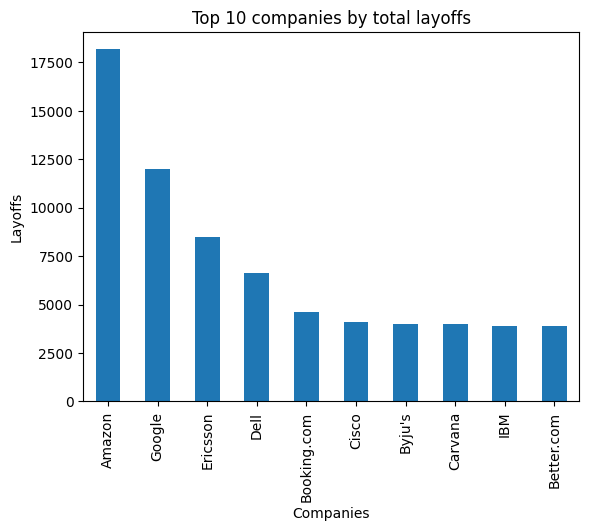

In [55]:
#plot for total layoffs by companies
layoff.sort_values(ascending=False).plot(kind='bar')
plt.title('Top 10 companies by total layoffs')
plt.xlabel('Companies')
plt.ylabel('Layoffs')

In [24]:
#find number of layoffs per month
df['month']=df['date'].dt.to_period('M').astype(str)
monthly=df.groupby("month")["total_laid_off"].sum().sort_values(ascending=False).head(10)
print("Number of layoffs per month:\n", monthly)

Number of layoffs per month:
 month
2023-01    39588.0
2022-11    26961.0
2023-02    23865.0
2020-04    11193.0
2020-05    10472.0
2022-10     9482.0
2022-06     9402.0
2022-07     8424.0
2022-05     7240.0
2020-07     5870.0
Name: total_laid_off, dtype: float64


Text(0, 0.5, 'Layoffs')

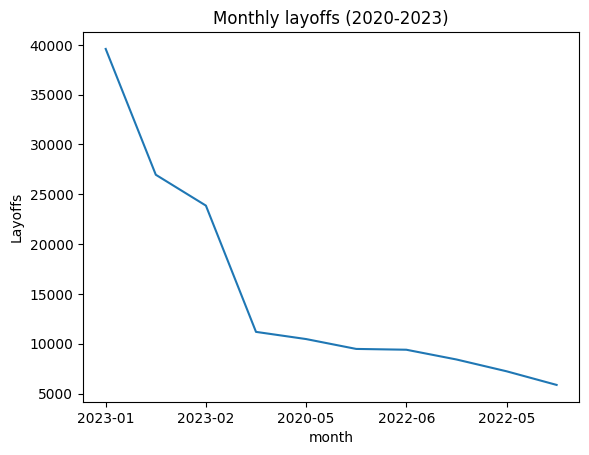

In [60]:
#plot graph for layoffs per month
monthly.sort_values(ascending=False).plot(kind='line')
plt.title('Monthly layoffs (2020-2023)')
plt.ylabel('Layoffs')

In [25]:
#find layoffs industry wise
industry_total=df.groupby("industry")["total_laid_off"].sum().sort_values(ascending=False).head(10)
print("Number of layoffs industry wise:\n", industry_total)

Number of layoffs industry wise:
 industry
Retail            30545.0
Consumer          20608.0
Food              14045.0
Hardware          13394.0
Transportation    13290.0
Other             13159.0
Finance           12045.0
Travel             9638.0
Crypto             9397.0
Real Estate        9053.0
Name: total_laid_off, dtype: float64


Text(0, 0.5, 'industries')

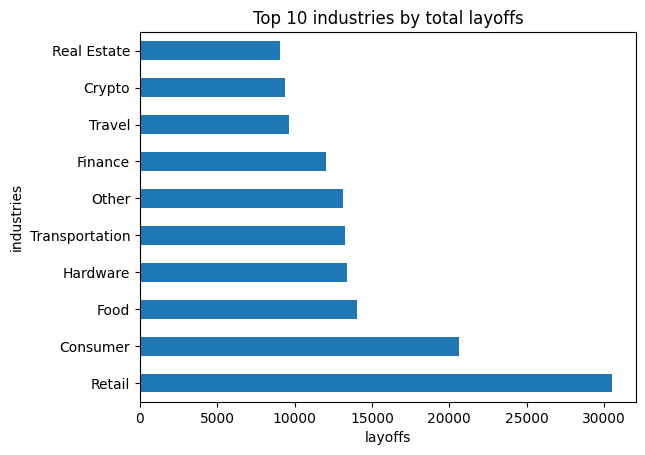

In [56]:
#plot graph for layoff by industry
industry_total.sort_values(ascending=False).plot(kind='barh')
plt.title('Top 10 industries by total layoffs')
plt.xlabel('layoffs')
plt.ylabel('industries')

#Key Findings

* Amazon (18,150) and Google (12,000) alone account for more layoffs than the next 8 companies combined
* Retail lost the most people overall, but Finance had the most layoff events.
* Funding size didn't protect against layoffs — the correlation between funds raised and layoff severity was weak